[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/18_pandas_series_temporelles.ipynb)



# Pandas et les séries temporelles

Une série temporelle est une suite de valeurs indexées par le temps : un cours de
bourse, une température relevée chaque heure, le trafic d'un site. Pandas est
construit pour ce genre de données, à condition que son index soit un
DatetimeIndex.

Ce notebook utilise le cours du Bitcoin en euros, téléchargé en direct. Une fois
l'index temporel en place, sélectionner une année, lisser le bruit ou changer de
fréquence devient trivial.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Télécharger les données, et le piège du MultiIndex |
| 2 | Le DatetimeIndex : sélectionner par date |
| 3 | `resample` : changer de fréquence |
| 4 | `rolling` : la moyenne glissante |
| 5 | `ewm` : la moyenne exponentielle |
| 6 | Assembler deux séries avec `merge` |
| 7 | Variation et volatilité |

## Trois pièges annoncés

`yfinance` renvoie des colonnes à deux niveaux qui cassent `btc['Close']`.

`resample('ME')` seul ne trace rien : il faut préciser une agrégation.

Et `ewm(alpha=0)` est interdit `alpha` doit être strictement entre 0 et 1.

Prérequis : le bloc NumPy, et des bases de Pandas.

## Note de reproductibilité

Ces données changent chaque jour, puisqu'une valeur s'ajoute à chaque séance. Un
lecteur qui réexécute obtiendra une série plus longue. Pour figer un résultat,
la section 1 montre comment sauvegarder en CSV.

Rien ici n'est un conseil d'investissement : c'est un jeu de données pour
s'exercer aux séries temporelles, pas une analyse de marché.

## 1. Télécharger les données

`yfinance` récupère l'historique directement, sans fichier à gérer.

In [1]:
!pip install -q yfinance

import yfinance as yf

btc = yf.download('BTC-EUR', start='2015-01-01', interval='1d')
print(btc.shape)
btc.head()

/tmp/ipykernel_1354/3469954492.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-EUR', start='2015-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

(4246, 5)


Price,Close,High,Low,Open,Volume
Ticker,BTC-EUR,BTC-EUR,BTC-EUR,BTC-EUR,BTC-EUR
Date,,,,,
2015-01-01,260.010742,264.909882,259.871704,264.909882,6649470
2015-01-02,262.548553,263.177216,259.896393,259.870117,6551088
2015-01-03,234.254517,262.646881,234.254517,262.393555,27547629
2015-01-04,221.157715,239.378296,214.694550,234.307861,46567135
2015-01-05,229.935501,232.746048,221.623627,221.901901,36829019


### Le piège du MultiIndex

Regarde les colonnes : elles ont deux niveaux.

In [2]:
print(btc.columns)

MultiIndex([( 'Close', 'BTC-EUR'),
            (  'High', 'BTC-EUR'),
            (   'Low', 'BTC-EUR'),
            (  'Open', 'BTC-EUR'),
            ('Volume', 'BTC-EUR')],
           names=['Price', 'Ticker'])


`yfinance` crée cette structure pour pouvoir télécharger plusieurs actifs d'un
coup. Avec un seul, ce second niveau ne sert à rien, et il casse l'accès
habituel :

```python
btc['Close'] # renvoie encore un DataFrame, pas la colonne attendue
```

On aplatit en ne gardant que le premier niveau :

In [3]:
btc.columns = btc.columns.get_level_values(0)
print(btc.columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume']


Maintenant `btc['Close']` donne bien la série des cours de clôture.

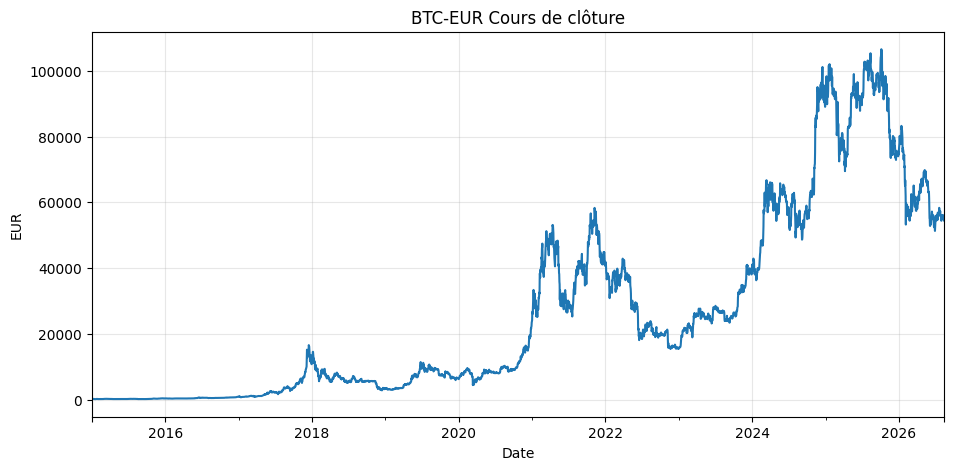

In [4]:
import matplotlib.pyplot as plt

btc['Close'].plot(figsize=(11, 5))
plt.title('BTC-EUR Cours de clôture')
plt.ylabel('EUR')
plt.grid(alpha=0.3)
plt.show()

### Figer les données

Pour qu'un lecteur obtienne exactement ta série, sauvegarde une fois puis relis
depuis le fichier :

```python
btc.to_csv('btc_eur.csv')

btc = pd.read_csv('btc_eur.csv', index_col='Date', parse_dates=True)
```

Deux arguments essentiels à la relecture. `index_col='Date'` reprend la date
comme index. `parse_dates=True` la convertit en vraies dates sans lui, ce
seraient des chaînes de caractères, et tout ce qui suit échouerait.

## 2. Le DatetimeIndex

C'est ce qui rend Pandas puissant sur les dates. L'index n'est pas une simple
liste de textes.

In [5]:
print(type(btc.index))
print(btc.index[:3])

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03'], dtype='datetime64[ns]', name='Date', freq=None)


`DatetimeIndex` permet de sélectionner par date avec une simple chaîne, sans
convertir quoi que ce soit.

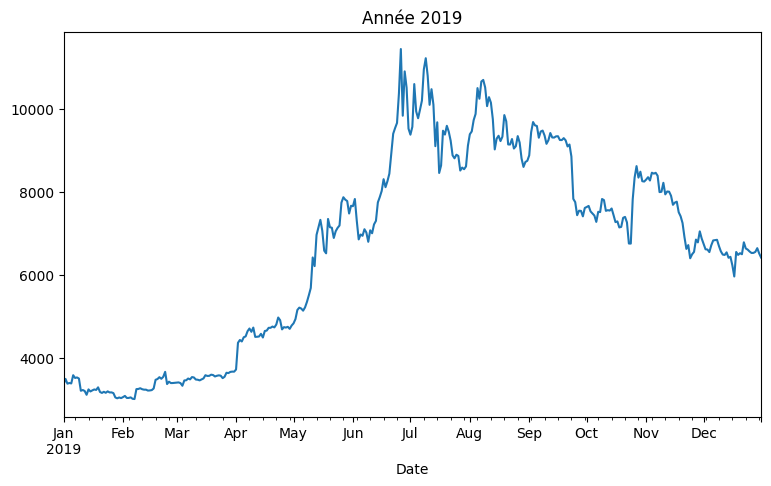

In [6]:
btc.loc['2019', 'Close'].plot(figsize=(9, 5))
plt.title('Année 2019')
plt.show()

`loc['2019']` comprend qu'on veut toute l'année. On peut affiner à volonté :

In [7]:
print('Un mois : btc.loc[\'2019-09\']')
print('Un jour : btc.loc[\'2019-09-15\']')
print('Un intervalle : btc.loc[\'2017\':\'2018\']')
print()
print('Septembre 2019 :', btc.loc['2019-09', 'Close'].shape[0], 'jours')

Un mois : btc.loc['2019-09']
Un jour : btc.loc['2019-09-15']
Un intervalle : btc.loc['2017':'2018']

Septembre 2019 : 30 jours


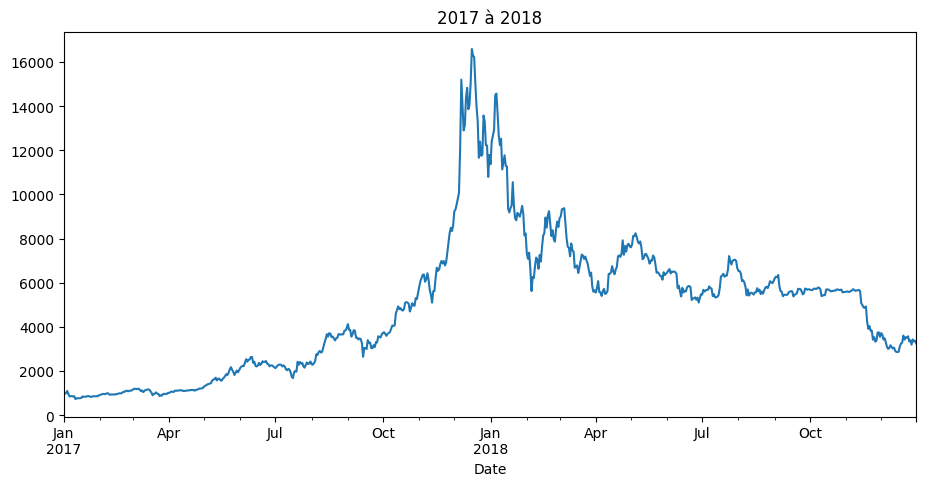

In [8]:
btc.loc['2017':'2018', 'Close'].plot(figsize=(11, 5))
plt.title('2017 à 2018')
plt.show()

La sélection par tranche `'2017':'2018'` inclut les deux bornes, contrairement
au slicing habituel de Python. C'est une exception propre à `loc` : les deux
extrémités sont comprises.

Si l'index n'était pas temporel, il faudrait le convertir :

```python
btc.index = pd.to_datetime(btc.index)
```

`to_datetime` reconnaît la plupart des formats de date automatiquement.

## 3. resample : changer de fréquence

`resample` regroupe les données selon une fréquence temporelle, puis applique une
agrégation. C'est l'équivalent temporel du `groupby`.

### Le piège : une agrégation est obligatoire

In [9]:
essai = btc.loc['2019', 'Close'].resample('ME')
print(type(essai))

<class 'pandas.core.resample.DatetimeIndexResampler'>


`resample('ME')` seul renvoie un objet intermédiaire, comme `groupby`. Il ne sait
pas encore quoi faire de chaque mois. Tenter de le tracer directement échoue :

```python
btc.loc['2019', 'Close'].resample('ME').plot() # AttributeError
```

Il faut préciser : moyenne, somme, dernier cours, maximum…

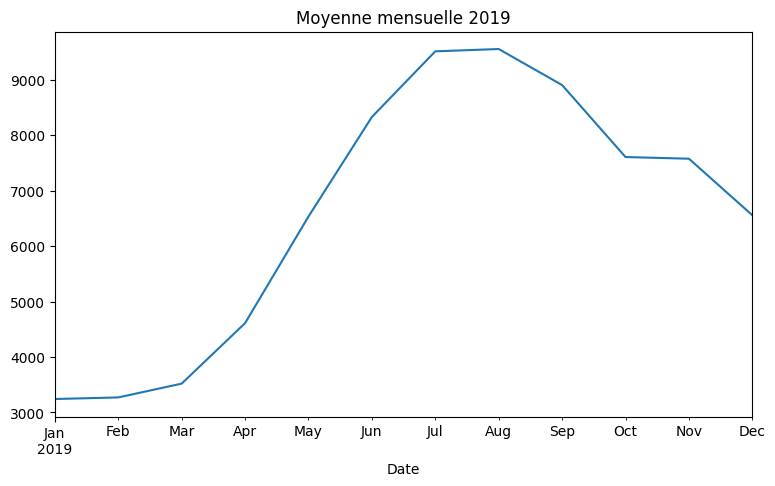

In [10]:
btc.loc['2019', 'Close'].resample('ME').mean().plot(figsize=(9, 5))
plt.title('Moyenne mensuelle 2019')
plt.show()

Douze points au lieu de 365. Le `'ME'` signifie month end.

Les codes de fréquence les plus utiles :

| Code | Période |
|---|---|
| `'D'` | jour |
| `'W'` | semaine |
| `'2W'` | deux semaines |
| `'ME'` | mois |
| `'QE'` | trimestre |
| `'YE'` | année |

### Choisir l'agrégation

Selon la question, on ne prend pas la même chose de chaque période.

In [11]:
serie = btc.loc['2019', 'Close']

print('moyenne du mois :', serie.resample('ME').mean().round(0).tolist()[:3])
print('dernier cours :', serie.resample('ME').last().round(0).tolist()[:3])
print('plus haut :', serie.resample('ME').max().round(0).tolist()[:3])
print('plus bas :', serie.resample('ME').min().round(0).tolist()[:3])

moyenne du mois : [3241.0, 3270.0, 3519.0]
dernier cours : [3020.0, 3389.0, 3658.0]
plus haut : [3573.0, 3654.0, 3659.0]
plus bas : [3015.0, 2998.0, 3318.0]


`mean` lisse, `last` donne le cours de clôture du mois, `max` et `min` les
extrêmes. Aucune n'est « la bonne » cela dépend de ce qu'on veut montrer.

### Plusieurs agrégations d'un coup

`agg` calcule plusieurs statistiques par période, comme au notebook 12.

In [12]:
resume = btc.loc['2019', 'Close'].resample('ME').agg(['mean', 'std', 'min', 'max'])
print(resume.round(0))

              mean     std     min      max
Date                                       
2019-01-31  3241.0   155.0  3015.0   3573.0
2019-02-28  3270.0   183.0  2998.0   3654.0
2019-03-31  3519.0    85.0  3318.0   3659.0
2019-04-30  4610.0   223.0  3711.0   4965.0
2019-05-31  6533.0  1010.0  4824.0   7867.0
2019-06-30  8328.0  1357.0  6791.0  11443.0
2019-07-31  9511.0   776.0  8453.0  11221.0
2019-08-31  9553.0   599.0  8598.0  10697.0
2019-09-30  8903.0   763.0  7406.0   9681.0
2019-10-31  7605.0   462.0  6749.0   8618.0
2019-11-30  7575.0   690.0  6394.0   8459.0
2019-12-31  6555.0   176.0  5955.0   6840.0


Le résultat est un DataFrame : une ligne par mois, une colonne par statistique.

### Superposer brut et lissé

Le vrai intérêt du resample : voir la tendance sous le bruit quotidien.

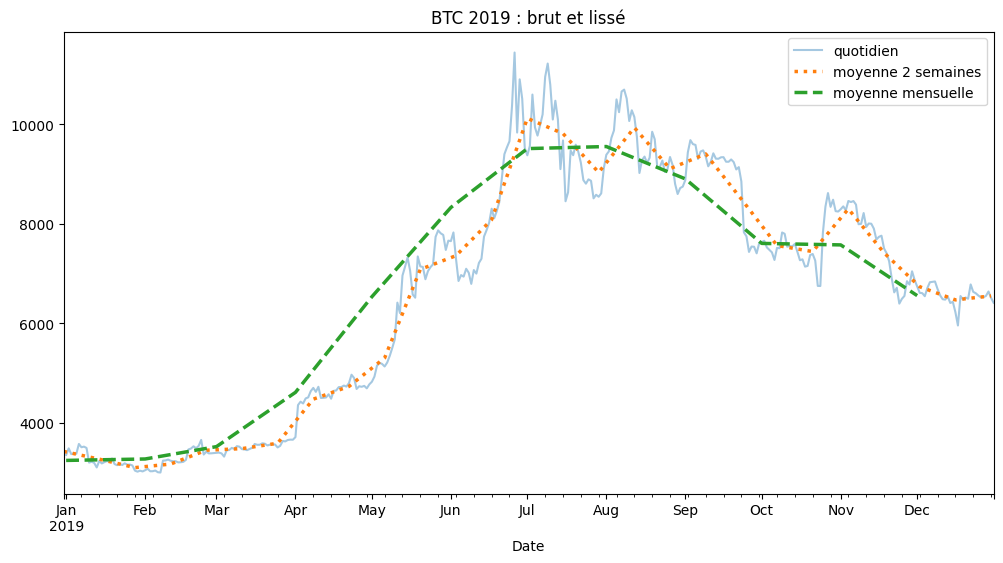

In [13]:
plt.figure(figsize=(12, 6))

btc.loc['2019', 'Close'].plot(alpha=0.4, label='quotidien')
btc.loc['2019', 'Close'].resample('2W').mean().plot(
    label='moyenne 2 semaines', lw=2.5, ls=':')
btc.loc['2019', 'Close'].resample('ME').mean().plot(
    label='moyenne mensuelle', lw=2.5, ls='--')

plt.legend()
plt.title('BTC 2019 : brut et lissé')
plt.show()

### Une bande min-max

`fill_between` dessine une zone entre deux courbes ici le plus haut et le plus
bas de chaque semaine, autour de la moyenne.

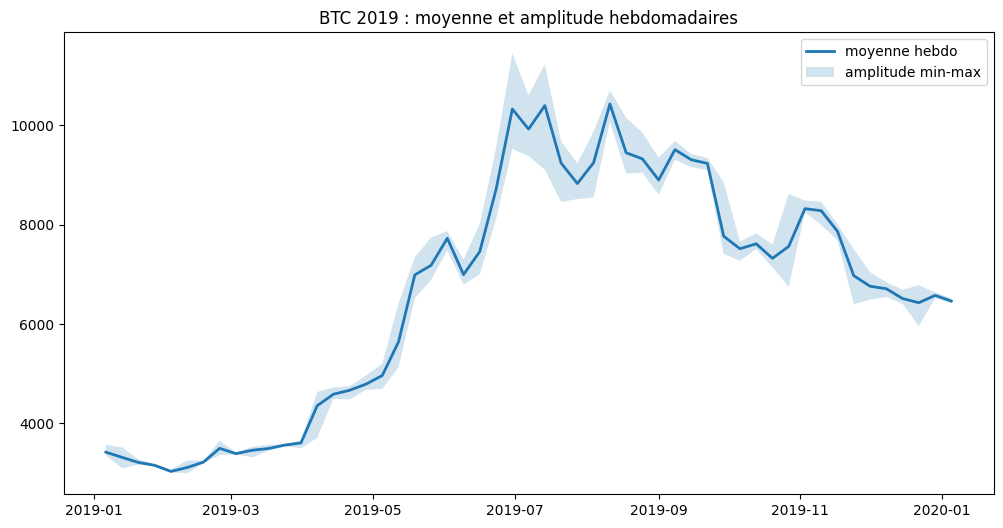

In [14]:
hebdo = btc.loc['2019', 'Close'].resample('W').agg(['mean', 'min', 'max'])

plt.figure(figsize=(12, 6))
plt.plot(hebdo.index, hebdo['mean'], label='moyenne hebdo', lw=2)
plt.fill_between(hebdo.index, hebdo['min'], hebdo['max'],
                 alpha=0.2, label='amplitude min-max')

plt.legend()
plt.title('BTC 2019 : moyenne et amplitude hebdomadaires')
plt.show()

La largeur de la bande révèle la volatilité : plus elle est épaisse, plus le
cours a bougé dans la semaine. C'est souvent plus parlant que la courbe seule.

## 4. rolling : la moyenne glissante

`resample` change la fréquence un point par mois. `rolling` garde tous les
points, mais lisse chacun avec ses voisins.

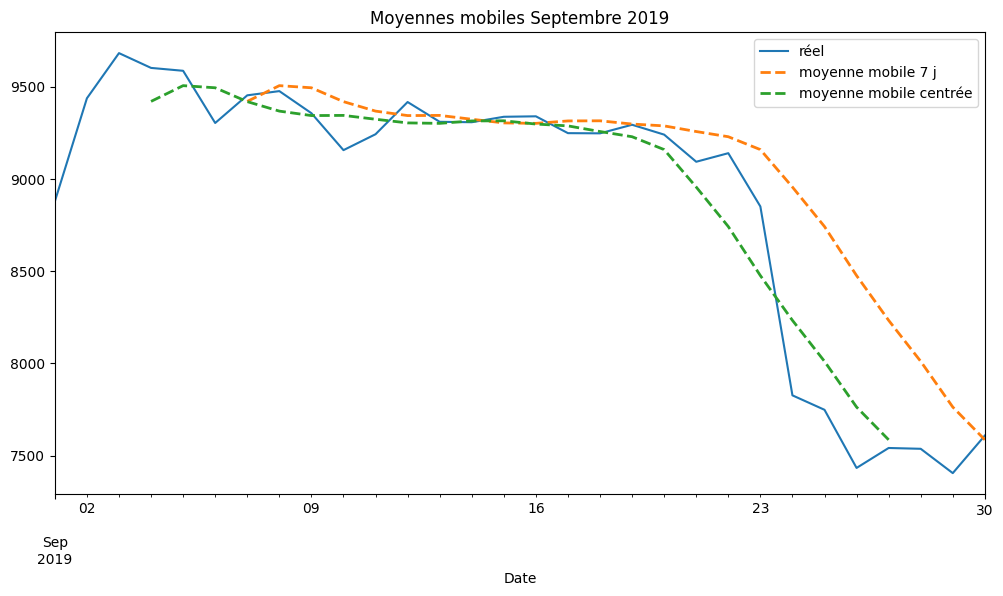

In [15]:
plt.figure(figsize=(12, 6))

serie = btc.loc['2019-09', 'Close']

serie.plot(label='réel', lw=1.5)
serie.rolling(window=7).mean().plot(label='moyenne mobile 7 j', lw=2, ls='--')
serie.rolling(window=7, center=True).mean().plot(
    label='moyenne mobile centrée', lw=2, ls='--')

plt.legend()
plt.title('Moyennes mobiles Septembre 2019')
plt.show()

`rolling(window=7)` calcule, pour chaque jour, la moyenne des 7 derniers jours.
La fenêtre glisse d'un jour à chaque pas c'est exactement la moyenne glissante
qu'on avait codée à la main sur le Titanic.

Deux points techniques.

Les 6 premiers jours sont `NaN` : il n'y a pas encore 7 valeurs pour calculer.

`center=True` centre la fenêtre sur le jour courant au lieu de la faire porter sur
le passé. La courbe centrée n'est pas décalée dans le temps, mais elle « voit »
le futur donc inutilisable pour de la prévision, seulement pour l'analyse.

In [16]:
exemple = btc.loc['2019-09', 'Close']
print('7 premières valeurs de la moyenne mobile :')
print(exemple.rolling(window=7).mean().head(8).round(0))

7 premières valeurs de la moyenne mobile :
Date
2019-09-01       NaN
2019-09-02       NaN
2019-09-03       NaN
2019-09-04       NaN
2019-09-05       NaN
2019-09-06       NaN
2019-09-07    9419.0
2019-09-08    9505.0
Name: Close, dtype: float64


## 5. ewm : la moyenne exponentielle

La moyenne mobile donne le même poids à chaque jour de la fenêtre. La moyenne
exponentielle donne plus de poids aux jours récents.

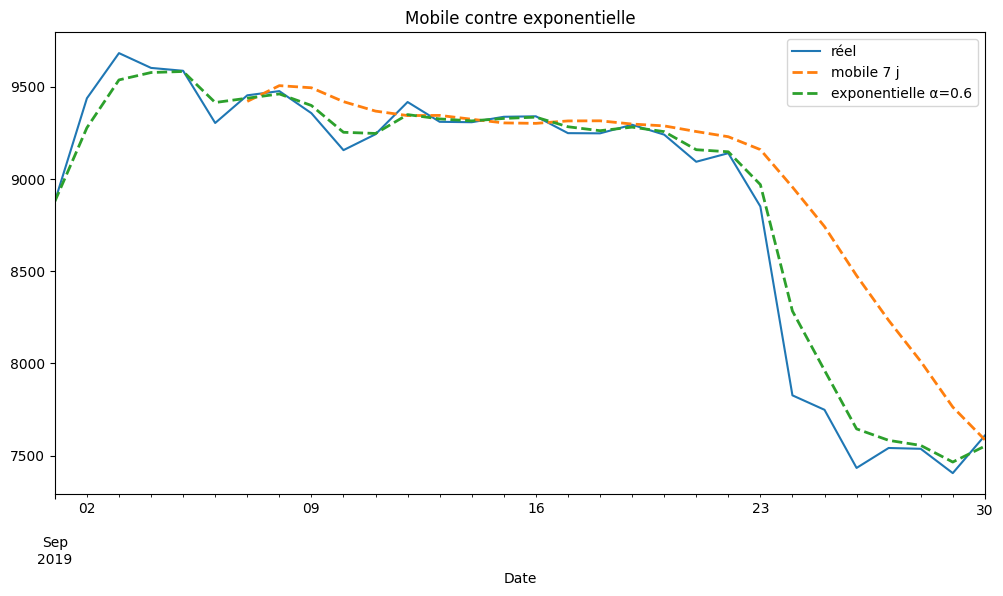

In [17]:
plt.figure(figsize=(12, 6))

serie = btc.loc['2019-09', 'Close']

serie.plot(label='réel', lw=1.5)
serie.rolling(7).mean().plot(label='mobile 7 j', lw=2, ls='--')
serie.ewm(alpha=0.6).mean().plot(label='exponentielle α=0.6', lw=2, ls='--')

plt.legend()
plt.title('Mobile contre exponentielle')
plt.show()

L'exponentielle réagit plus vite aux changements récents, parce qu'elle ne se
traîne pas une valeur d'il y a une semaine avec le même poids qu'hier.

### Le piège : alpha strictement entre 0 et 1

`alpha` règle la réactivité. Proche de 1, la courbe colle au réel ; proche de 0,
elle est très lissée. Mais les bornes 0 et 1 sont interdites.

In [18]:
serie = btc.loc['2019-09', 'Close']

try:
    serie.ewm(alpha=0).mean()
except ValueError as e:
    print('ValueError :', str(e)[:70])

ValueError : alpha must satisfy: 0 < alpha <= 1


`alpha=0` voudrait dire « ignorer toute nouvelle valeur » : la moyenne ne
bougerait jamais, ce qui n'a pas de sens.

D'où l'erreur classique : une boucle `np.arange(0, 1, 0.2)` commence à 0 et plante
au premier tour. Il faut démarrer après.

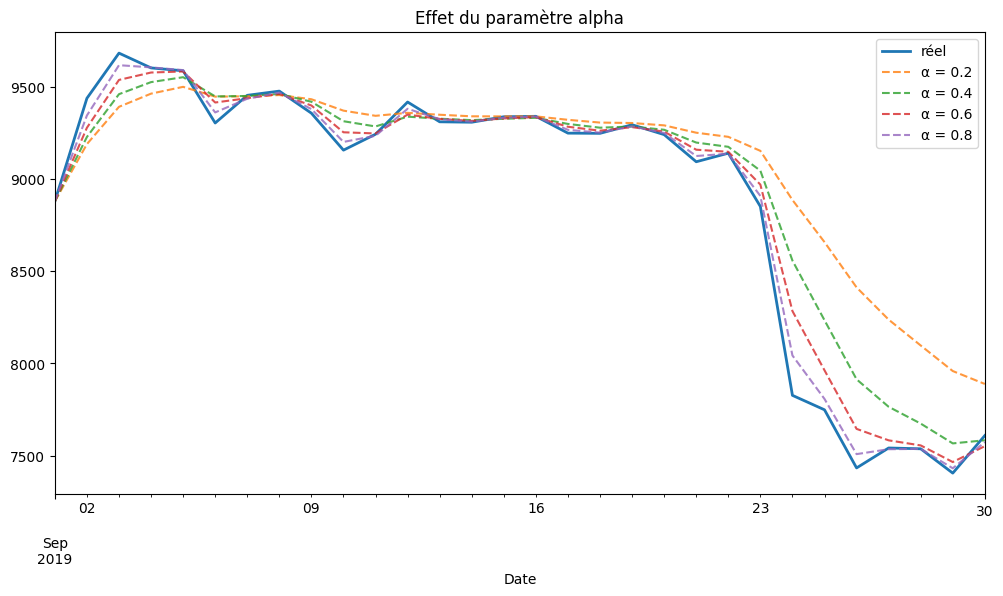

In [19]:
import numpy as np

plt.figure(figsize=(12, 6))
serie = btc.loc['2019-09', 'Close']
serie.plot(label='réel', lw=2)

for a in np.arange(0.2, 1, 0.2): # commence à 0.2, pas 0
    serie.ewm(alpha=a).mean().plot(label=f'α = {a:.1f}', ls='--', alpha=0.8)

plt.legend()
plt.title("Effet du paramètre alpha")
plt.show()

On voit la progression : plus `alpha` est petit, plus la courbe est lisse et lente
à réagir. C'est le compromis habituel du lissage trop réactif, on garde le
bruit ; trop lisse, on rate les vrais changements.

La moyenne exponentielle est la plus utilisée en finance, précisément parce
qu'elle privilégie l'information récente.

## 6. Assembler deux séries

Téléchargeons l'Ethereum pour le comparer au Bitcoin.

In [20]:
eth = yf.download('ETH-EUR', start='2018-01-01', interval='1d')
eth.columns = eth.columns.get_level_values(0) # même aplatissement
print(eth.shape)
eth.head()

/tmp/ipykernel_1354/4120466825.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download('ETH-EUR', start='2018-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

(3150, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-01,643.384949,652.108337,617.873291,629.692566,2161512306
2018-01-02,733.308960,761.786987,643.192871,643.139343,4795083127
2018-01-03,801.598633,811.450562,721.964417,734.599121,4240765975
2018-01-04,812.963684,866.064453,784.157471,800.760193,5389408069
2018-01-05,829.497803,892.958557,794.157959,808.677246,5556326758


### merge : fusionner sur les dates

`merge` combine deux tableaux sur une clé commune ici la date.

In [21]:
import pandas as pd

btc_eth = pd.merge(btc, eth, on='Date', how='inner', suffixes=('_btc', '_eth'))
print(btc_eth.shape)
print(btc_eth.columns.tolist())

(3150, 10)
['Close_btc', 'High_btc', 'Low_btc', 'Open_btc', 'Volume_btc', 'Close_eth', 'High_eth', 'Low_eth', 'Open_eth', 'Volume_eth']


Le `on='Date'` fonctionne parce que `yfinance` a nommé l'index `Date`. Pandas
accepte alors de fusionner sur un index nommé. Si l'index n'avait pas de nom, il
faudrait `left_index=True, right_index=True`.

`suffixes` distingue les colonnes homonymes : `Close_btc` et `Close_eth`.

### Le rôle de how

C'est le point qui mérite l'attention. `how` décide quelles dates on garde.

| `how` | Dates conservées |
|---|---|
| `'inner'` | présentes dans les deux (intersection) |
| `'outer'` | présentes dans l'un ou l'autre (union) |
| `'left'` | celles du premier (btc) |
| `'right'` | celles du second (eth) |

In [22]:
for methode in ['inner', 'outer', 'left', 'right']:
    fusion = pd.merge(btc, eth, on='Date', how=methode, suffixes=('_btc', '_eth'))
    print(f'{methode:<6} : {len(fusion)} lignes')

inner  : 3150 lignes
outer  : 4246 lignes
left   : 4246 lignes
right  : 3150 lignes


`inner` donne le moins de lignes : il ne garde que les dates où les deux
cryptos ont une valeur. Comme BTC et ETH n'ont pas commencé à la même date sur
Yahoo, `inner` coupe le début.

`outer` garde tout et met des `NaN` là où une valeur manque. Pour comparer deux
séries, `inner` est généralement le bon choix on ne compare que les dates
communes.

### Comparer les deux

Attention à l'échelle : le BTC vaut des dizaines de milliers, l'ETH des milliers.
Un tracé direct écraserait l'ETH.

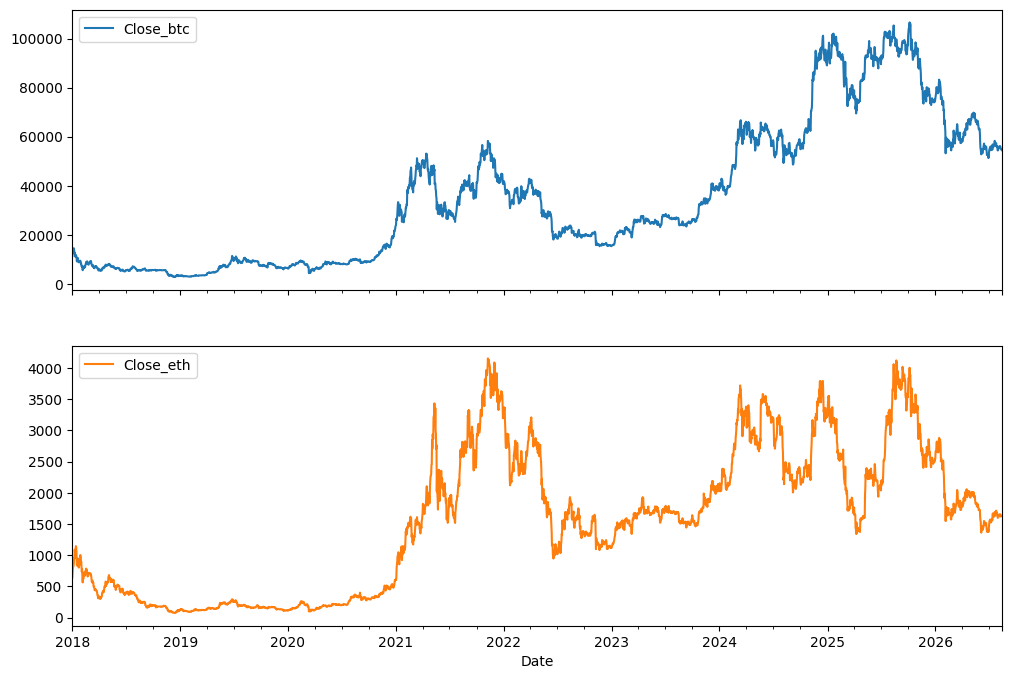

In [23]:
btc_eth[['Close_btc', 'Close_eth']].plot(subplots=True, figsize=(12, 8))
plt.show()

`subplots=True` trace chaque colonne sur son propre graphique, avec sa propre
échelle. C'est la façon honnête de comparer deux actifs d'ordres de grandeur
différents.

### La corrélation

In [24]:
correlation = btc_eth[['Close_btc', 'Close_eth']].corr()
print(correlation.round(3))

Price      Close_btc  Close_eth
Price                          
Close_btc      1.000      0.828
Close_eth      0.828      1.000


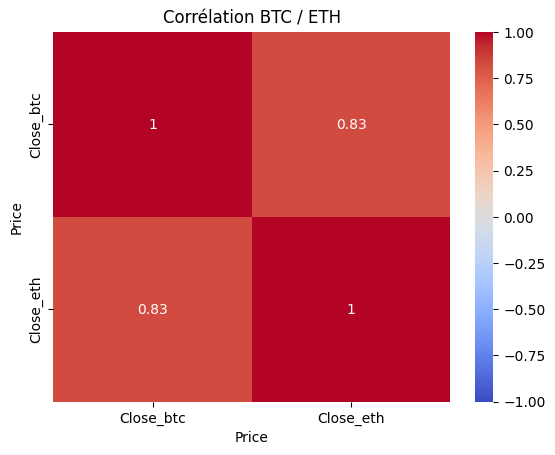

In [25]:
import seaborn as sns

sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Corrélation BTC / ETH')
plt.show()

Une corrélation proche de 1 signifie que les deux cryptos montent et descendent
ensemble.

Attention à l'interprétation. Cette corrélation porte sur les prix, qui
tous deux augmentent globalement sur la période deux séries croissantes sont
mécaniquement corrélées, même sans lien réel. Pour une mesure plus juste, on
corrèle les rendements plutôt que les prix :

```python
btc_eth[['Close_btc', 'Close_eth']].pct_change().corr()
```

C'est un piège statistique classique : deux tendances parallèles gonflent la
corrélation. Le `annot=True` et le `vmin/vmax` de la heatmap rendent au moins la
valeur lisible et bornée.

## 7. Variation et volatilité

`diff` donne la variation absolue d'un jour à l'autre.

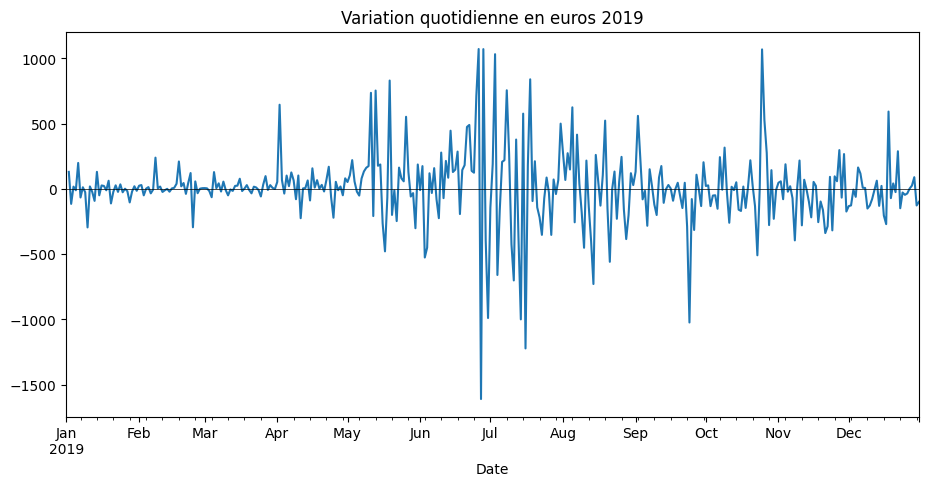

In [26]:
btc.loc['2019', 'Close'].diff().plot(figsize=(11, 5))
plt.title('Variation quotidienne en euros 2019')
plt.axhline(0, color='black', lw=0.5)
plt.show()

La première valeur est `NaN` : pas de jour précédent. La courbe oscille autour de
zéro positif les jours de hausse, négatif les jours de baisse.

L'amplitude des oscillations est la volatilité : plus elles sont grandes, plus
le cours bouge.

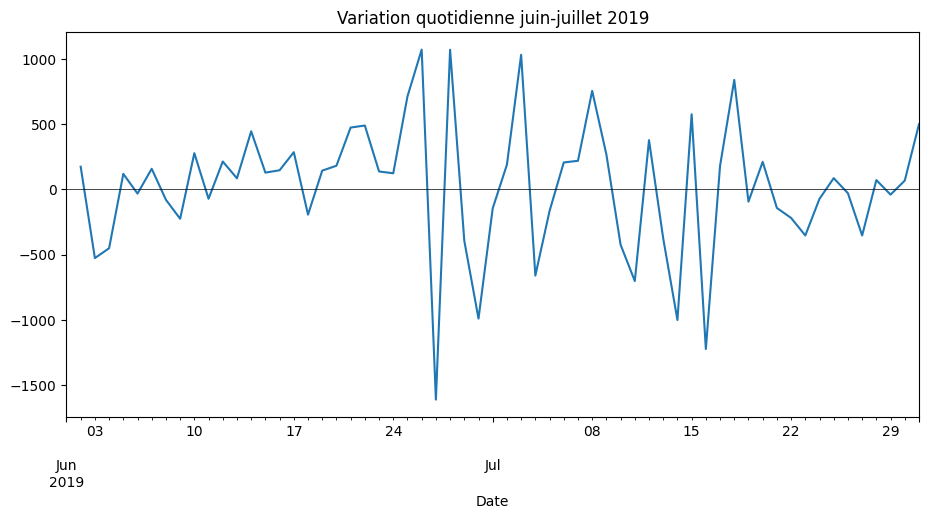

In [27]:
btc.loc['2019-06':'2019-07', 'Close'].diff().plot(figsize=(11, 5))
plt.title('Variation quotidienne juin-juillet 2019')
plt.axhline(0, color='black', lw=0.5)
plt.show()

### diff ou pct_change ?

`diff` donne des euros, `pct_change` des pourcentages. Sur une crypto dont le prix
varie d'un facteur 10, le pourcentage est bien plus parlant.

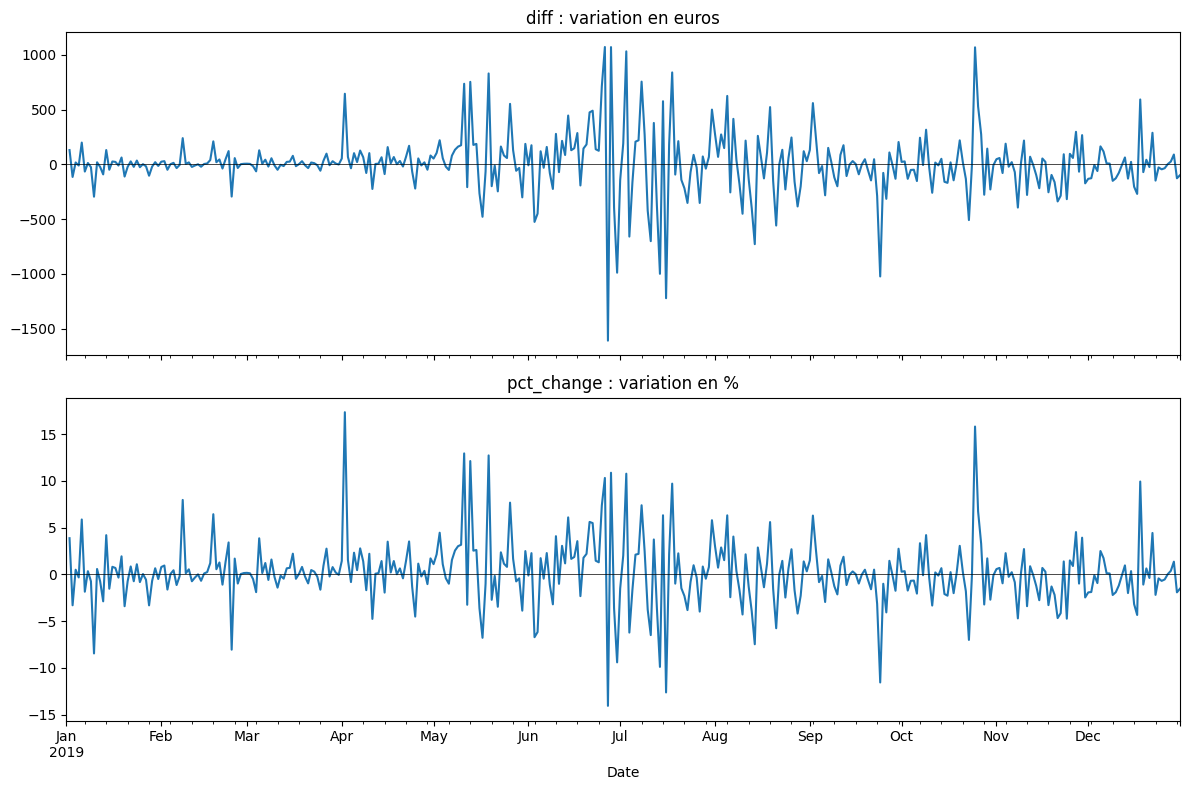

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

btc.loc['2019', 'Close'].diff().plot(ax=ax[0])
ax[0].set_title('diff : variation en euros')
ax[0].axhline(0, color='black', lw=0.5)

(btc.loc['2019', 'Close'].pct_change() * 100).plot(ax=ax[1])
ax[1].set_title('pct_change : variation en %')
ax[1].axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

Une variation de 500 € ne veut pas dire la même chose selon que le cours est à
3000 ou à 10000. Le pourcentage neutralise le niveau du prix, ce qui permet de
comparer la volatilité entre périodes.

### La volatilité comme écart-type glissant

La mesure standard de la volatilité est l'écart-type des rendements sur une
fenêtre glissante.

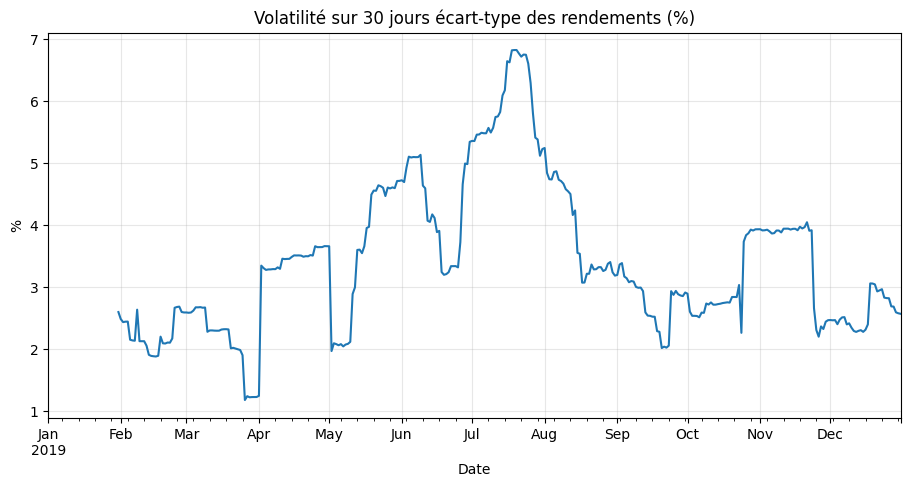

In [29]:
volatilite = btc.loc['2019', 'Close'].pct_change().rolling(window=30).std() * 100

volatilite.plot(figsize=(11, 5))
plt.title('Volatilité sur 30 jours écart-type des rendements (%)')
plt.ylabel('%')
plt.grid(alpha=0.3)
plt.show()

Cette courbe combine trois outils du notebook : `pct_change` pour les rendements,
`rolling(30)` pour la fenêtre glissante, `std` pour la dispersion. Les pics
correspondent aux périodes agitées.

C'est la mesure de volatilité utilisée en finance, et un bon exemple de la façon
dont les briques Pandas se combinent.

## 8. Mémo

### Sélectionner par date

| Écriture | Effet |
|---|---|
| `btc.loc['2019']` | toute l'année |
| `btc.loc['2019-09']` | un mois |
| `btc.loc['2017':'2018']` | un intervalle, bornes incluses |

### Changer de fréquence

| Écriture | Effet |
|---|---|
| `.resample('ME').mean()` | un point par mois, moyenné |
| `.resample('W').last()` | dernier cours de chaque semaine |
| `.resample('ME').agg([...])` | plusieurs statistiques |

### Lisser

| Écriture | Effet |
|---|---|
| `.rolling(7).mean()` | moyenne des 7 derniers jours |
| `.rolling(7, center=True)` | fenêtre centrée |
| `.ewm(alpha=0.6).mean()` | moyenne exponentielle |

### Variation

| Écriture | Effet |
|---|---|
| `.diff()` | variation absolue |
| `.pct_change()` | variation en proportion |
| `.pct_change().rolling(30).std()` | volatilité |

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| Colonnes yfinance | MultiIndex, casse `btc['Close']` |
| `resample('ME')` seul | pas de `.plot`, agrégation obligatoire |
| Code `'M'` | déprécié, utiliser `'ME'` |
| `ewm(alpha=0)` | interdit, borne exclue |
| `merge how='inner'` | coupe les dates non communes |
| Corrélation des prix | gonflée par la tendance commune |
| Données retéléchargées | changent chaque jour |

## 9. Exercices

**Exercice 1**

Télécharge un actif de ton choix. Trace sur un même graphique le cours quotidien,
sa moyenne mobile 30 jours et sa moyenne mobile 90 jours. Que révèle le croisement
des deux moyennes ?

C'est le principe du « croisement de moyennes », une stratégie de trading
classique sans que ce soit un conseil.

**Exercice 2**

Écris une fonction `resume_annuel(serie)` qui, pour chaque année, renvoie le cours
de début, de fin, le plus haut, le plus bas, et la performance en pourcentage.
Utilise `resample('YE')` et `agg`.

**Exercice 3**

Ce code prétend calculer la corrélation entre les rendements de deux actifs :

```python
correlation = pd.merge(btc, eth, on='Date', how='outer')[['Close_x', 'Close_y']].corr()
```

Il contient deux problèmes. Trouve-les en affichant le nombre de `NaN` du tableau
fusionné, explique pourquoi la corrélation obtenue est trompeuse, puis corrige
pour obtenir la corrélation des rendements sur les dates communes.

## Pour continuer

Le notebook suivant porte sur Seaborn, qui simplifie les visualisations
statistiques la heatmap de corrélation vue ici n'en est qu'un aperçu.

Puis viendra scikit-learn, où ces séries pourront servir à construire des
variables : moyennes mobiles, volatilité et rendements deviennent les colonnes
d'un modèle prédictif.

In [36]:
# Exercice 1

/tmp/ipykernel_1354/3894987128.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actif = yf.download('AAPL', start='2020-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


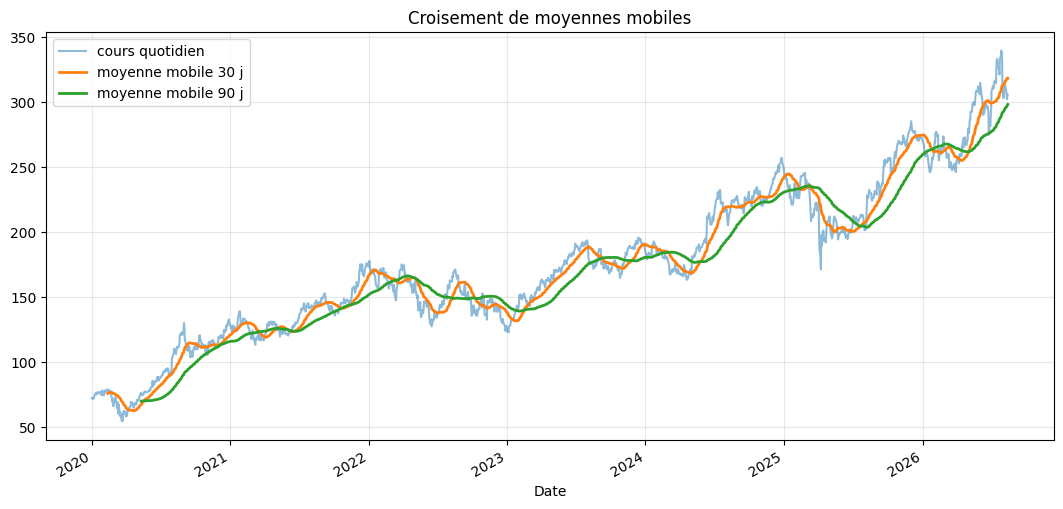

In [31]:
import yfinance as yf
import matplotlib.pyplot as plt

actif = yf.download('AAPL', start='2020-01-01', interval='1d')
actif.columns = actif.columns.get_level_values(0) # aplatir le MultiIndex
cours = actif['Close']

plt.figure(figsize=(13, 6))
cours.plot(label='cours quotidien', alpha=0.5)
cours.rolling(30).mean().plot(label='moyenne mobile 30 j', lw=2)
cours.rolling(90).mean().plot(label='moyenne mobile 90 j', lw=2)
plt.legend()
plt.title('Croisement de moyennes mobiles')
plt.grid(alpha=0.3)
plt.show()

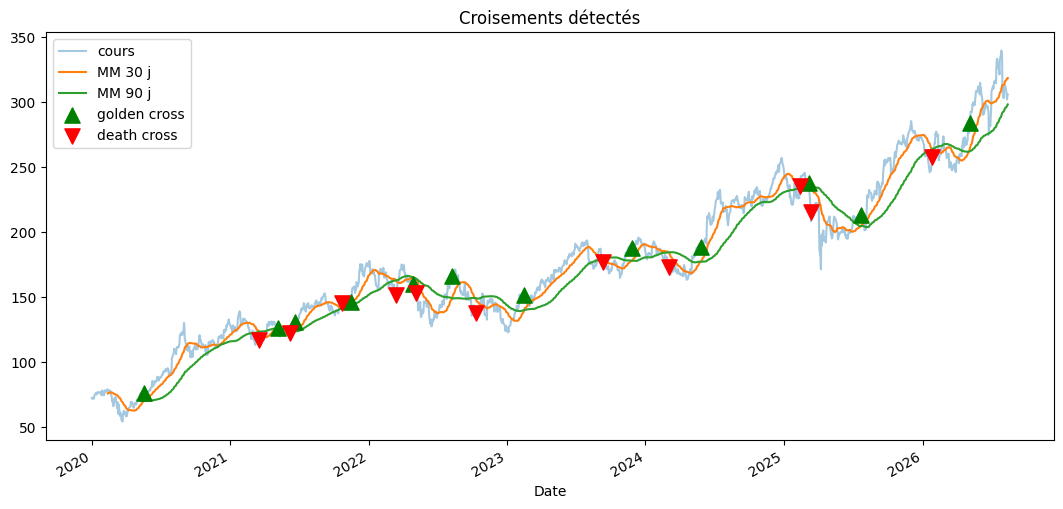

In [32]:
import numpy as np

rapide = cours.rolling(30).mean()
lente = cours.rolling(90).mean()

au_dessus = rapide > lente # série de booléens
croisements = au_dessus.astype(int).diff() # +1 ou -1 aux changements

golden = croisements[croisements == 1].index # rapide passe au-dessus
death = croisements[croisements == -1].index # rapide passe en dessous

plt.figure(figsize=(13, 6))
cours.plot(alpha=0.4, label='cours')
rapide.plot(label='MM 30 j', lw=1.5)
lente.plot(label='MM 90 j', lw=1.5)

plt.scatter(golden, cours[golden], marker='^', s=120, color='green',
            zorder=5, label='golden cross')
plt.scatter(death, cours[death], marker='v', s=120, color='red',
            zorder=5, label='death cross')

plt.legend()
plt.title('Croisements détectés')
plt.show()

In [33]:
# Exericice 2

In [34]:
def resume_annuel(serie):
    """Pour chaque année : cours de début, de fin, extrêmes, et performance %."""
    resume = serie.resample('YE').agg(['first', 'last', 'min', 'max'])

    resume['performance_%'] = (resume['last'] / resume['first'] - 1) * 100

    resume.index = resume.index.year # 2018 au lieu de 2018-12-31
    return resume.round(2)

In [35]:
btc = yf.download('BTC-EUR', start='2018-01-01', interval='1d')
btc.columns = btc.columns.get_level_values(0)

print(resume_annuel(btc['Close']))

/tmp/ipykernel_1354/3470825043.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-EUR', start='2018-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed

         first      last       min        max  performance_%
Date                                                        
2018  11372.47   3256.93   2862.24   14571.83         -71.36
2019   3353.51   6411.46   2998.16   11443.04          91.19
2020   6417.78  23741.74   4444.24   23741.74         269.94
2021  24165.56  40712.72  24165.56   58305.04          68.47
2022  41926.34  15426.75  15408.91   42877.15         -63.21
2023  15528.42  38291.84  15528.42   40995.44         146.59
2024  40018.61  90269.89  36317.15  101138.94         125.57
2025  91219.30  74586.57  69481.53  106538.16         -18.23
2026  75510.03  54425.17  51308.39   83236.70         -27.92


In [36]:
def resume_annuel_complet(serie):
    resume = serie.resample('YE').agg(['first', 'last', 'min', 'max', 'mean', 'std'])
    resume['perf_%'] = (resume['last'] / resume['first'] - 1) * 100
    resume['amplitude_%'] = (resume['max'] / resume['min'] - 1) * 100
    resume.index = resume.index.year
    return resume.round(2)

In [37]:
print(resume_annuel_complet(btc['Close']))

         first      last       min        max      mean       std  perf_%  \
Date                                                                        
2018  11372.47   3256.93   2862.24   14571.83   6374.03   1935.30  -71.36   
2019   3353.51   6411.46   2998.16   11443.04   6619.37   2384.03   91.19   
2020   6417.78  23741.74   4444.24   23741.74   9637.35   3356.54  269.94   
2021  24165.56  40712.72  24165.56   58305.04  40206.82   8723.94   68.47   
2022  41926.34  15426.75  15408.91   42877.15  26452.20   8521.85  -63.21   
2023  15528.42  38291.84  15528.42   40995.44  26642.02   5330.81  146.59   
2024  40018.61  90269.89  36317.15  101138.94  61120.03  14499.99  125.57   
2025  91219.30  74586.57  69481.53  106538.16  89871.92   9310.76  -18.23   
2026  75510.03  54425.17  51308.39   83236.70  61860.42   7601.50  -27.92   

      amplitude_%  
Date               
2018       409.11  
2019       281.67  
2020       434.21  
2021       141.27  
2022       178.26  
2023       1

In [38]:
# Exercice 3

In [39]:
correlation = pd.merge(btc, eth, on='Date', how='outer')[['Close_x', 'Close_y']].corr()

In [40]:
fusion = pd.merge(btc, eth, on='Date', how='outer', suffixes=('_btc', '_eth'))

print('lignes totales :', len(fusion))
print('NaN dans Close_btc :', fusion['Close_btc'].isna().sum())
print('NaN dans Close_eth :', fusion['Close_eth'].isna().sum())

lignes totales : 3150
NaN dans Close_btc : 0
NaN dans Close_eth : 0


In [41]:
correlation = fusion[['Close_btc', 'Close_eth']].corr()
print('Corrélation des prix :')
print(correlation.round(3))

Corrélation des prix :
Price      Close_btc  Close_eth
Price                          
Close_btc      1.000      0.828
Close_eth      0.828      1.000


In [42]:
correlation = fusion[['Close_btc', 'Close_eth']].corr()
print('Corrélation des prix :')
print(correlation.round(3))

Corrélation des prix :
Price      Close_btc  Close_eth
Price                          
Close_btc      1.000      0.828
Close_eth      0.828      1.000


In [43]:
btc_eth = pd.merge(btc, eth, on='Date', how='inner', suffixes=('_btc', '_eth'))

rendements = btc_eth[['Close_btc', 'Close_eth']].pct_change().dropna()

correlation = rendements.corr()
print('Corrélation des rendements :')
print(correlation.round(3))

Corrélation des rendements :
Price      Close_btc  Close_eth
Price                          
Close_btc      1.000      0.815
Close_eth      0.815      1.000


In [44]:
prix = btc_eth[['Close_btc', 'Close_eth']].corr().iloc[0, 1]
rend = btc_eth[['Close_btc', 'Close_eth']].pct_change().corr().iloc[0, 1]

print(f'Corrélation des prix : {prix:.3f}')
print(f'Corrélation des rendements : {rend:.3f}')

Corrélation des prix : 0.828
Corrélation des rendements : 0.815
